# MAE 223 — Tutorial: SAFARI Sea Surface Temperature

## Background

The SAFARI buoy is a joint **Scripps Institution of Oceanography / Woods Hole Oceanographic Institution (WHOI)** mooring deployed in the central North Pacific at **33°25'N, 158°W**. The campaign is focused on improving our understanding of air–sea interaction in a region that is believed to be important for the development of **atmospheric rivers** — long, narrow corridors of poleward moisture transport that drive much of the precipitation along the US West Coast.

Ocean surface temperature is a key variable in air–sea interaction. Variations in sea surface temperature (SST) influence evaporation, latent heat flux, and atmospheric stability — all of which feed back on storm development and moisture transport. Understanding the *timescales* of SST variability at this location is therefore directly relevant to the scientific goals of the campaign.

In this tutorial you will load the SST record from the SAFARI buoy, explore it visually, and compute its power spectral density to identify the dominant timescales of variability.

---

**The `spectrumCB` function is defined in the next cell. Run it before proceeding.**

In [6]:
import numpy as np
from scipy.signal import detrend as scipy_detrend


def spectrumCB(time, data, chunk):
    """
    Compute a one-sided Power Spectral Density (PSD) using Welch's method:
    50% overlapping segments, linear detrending, FFT, and ensemble averaging.

    Parameters
    ----------
    time  : array-like  — time in decimal days
    data  : array-like  — data values, NaN-free
    chunk : int         — samples per segment

    Returns
    -------
    f        : ndarray  — one-sided frequency vector [cpd]
    a        : ndarray  — averaged PSD [units² / cpd]
    parseval : float    — ratio ∫PSD df / var(data); should be ≈ 1.0
    """
    data  = np.asarray(data,  dtype=float)
    time  = np.asarray(time,  dtype=float)
    chunk = int(chunk)

    # split into 50% overlapping segments
    segments = []
    step = chunk // 2
    ind  = 0
    while ind + chunk <= len(data):
        segments.append(data[ind : ind + chunk])
        ind += step

    # frequency vector
    dt = np.nanmean(np.diff(time))
    fn = 1.0 / (2.0 * dt)
    N  = chunk
    df = 1.0 / (dt * N)
    f  = np.arange(0, fn + df / 2, df)
    nf = len(f)

    # compute and average PSD
    A = np.empty((len(segments), nf))
    for i, seg in enumerate(segments):
        seg_dt   = scipy_detrend(seg)
        fft_vals = np.fft.fft(seg_dt)
        amp = np.abs(fft_vals[:nf]) ** 2
        amp = amp / N ** 2
        amp = amp * 2
        amp = amp / df
        A[i] = amp
    a = A.mean(axis=0)

    # Parseval check
    #variance = np.nanstd(data) ** 2
    variance = np.mean([np.var(scipy_detrend(seg)) for seg in segments])
    parseval = np.trapezoid(a, f) / variance
    print(f"  Segments used:  {len(segments)}")
    print(f"  Parseval check: {parseval:.4f}  (ideal = 1.00)")
    return f, a, parseval


## Exercise 1 — Load and Inspect the Data

Load `safari_sst.json` and print the metadata. Then extract the timestamps and SST values.

The file has three keys: `'metadata'`, `'time'`, and `'sst'`. Timestamps are ISO 8601 strings (`'%Y-%m-%dT%H:%M'`). SST is in degrees Celsius, sampled hourly with no missing values.

In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Load the data
with open('safari_sst.json') as f:
    safari = json.load(f)

# YOUR CODE HERE — print the metadata
    # print(safari["metadata"])
    metadata = safari['metadata']
    print("METADATA")
    for k, v in metadata.items():
        print(f"  {k}: {v}")

# YOUR CODE HERE — parse timestamps into decimal days since the record start
# Hint: same pattern as the demo notebook
#   1. Parse each string with datetime.strptime(s, '%Y-%m-%dT%H:%M')
#   2. Subtract the first timestamp
#   3. Convert to days via .total_seconds() / 86400
# Store result as: time_sst  (decimal days)
raw_times = safari['time']
datetimes = [datetime.strptime(s, '%Y-%m-%dT%H:%M') for s in raw_times]
t0 = datetimes[0]
time_sst = np.array([(dt - t0).total_seconds() / 86400 for dt in datetimes])

# YOUR CODE HERE — extract SST as a numpy float array
# Store result as: sst  (degrees C)
sst = np.array(safari['sst'], dtype=float)

# YOUR CODE HERE — print a summary: record length, dt, SST range
dt_hours = np.diff(time_sst).mean() * 24
print("\nSUMMARY")
print(f"  Record length: {time_sst[-1]:.2f} days  ({len(time_sst)} samples)")
print(f"  dt: {dt_hours:.2f} hours")
print(f"  SST range: {sst.min():.4f} °C  —  {sst.max():.4f} °C")



METADATA
  source: SAFARI 2025 buoy — Scripps Institution of Oceanography / WHOI joint mooring
  location: 33 25 N, 158 W (central North Pacific)
  instrument: SeaBird SBE37 CTD
  variable: Near-surface ocean temperature
  units: degrees C
  start: 2025-11-20T23:00
  end: 2026-04-02T14:00
  n_samples: 3184
  n_nulls: 0
  dt_hours: 1.0

SUMMARY
  Record length: 132.62 days  (3184 samples)
  dt: 1.00 hours
  SST range: 15.7600 °C  —  21.2800 °C


## Exercise 2 — Plot the Full SST Time Series

Plot the entire SST record against time. Label your axes and give the plot a descriptive title.

Look at the record carefully before moving on:
- What is the overall trend?
- Can you see variability at multiple timescales?
- Are there any obvious events or anomalies?

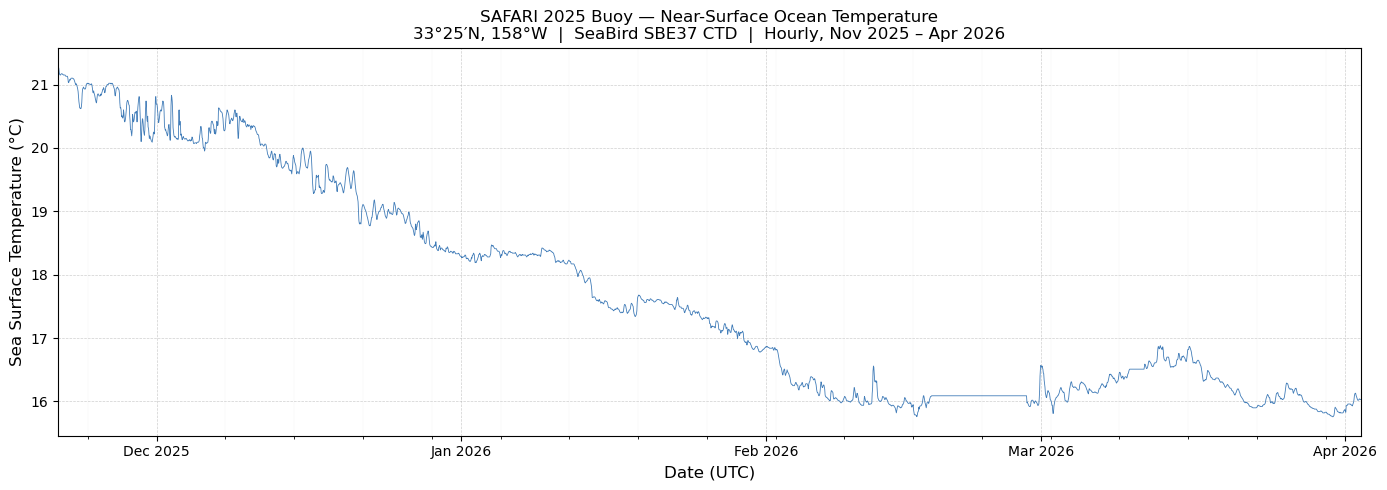

In [8]:
# YOUR CODE HERE — plot the full SST time series
# Include: axis labels, title, grid

%matplotlib inline

import json
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

with open('safari_sst.json', 'r') as f:
    safari = json.load(f)

raw_times = safari['time']
datetimes = [datetime.strptime(s, '%Y-%m-%dT%H:%M') for s in raw_times]
t0 = datetimes[0]
time_sst = np.array([(dt - t0).total_seconds() / 86400 for dt in datetimes])
sst = np.array (safari['sst'], dtype=float)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(datetimes, sst, color='#2166ac', linewidth=0.6, alpha=0.85)

ax.set_xlabel('Date (UTC)', fontsize=12)
ax.set_ylabel('Sea Surface Temperature (°C)', fontsize=12)
ax.set_title(
    'SAFARI 2025 Buoy — Near-Surface Ocean Temperature\n'
    '33°25′N, 158°W  |  SeaBird SBE37 CTD  |  Hourly, Nov 2025 – Apr 2026',
    fontsize=12
)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax.set_xlim(datetimes[0], datetimes[-1])
ax.set_ylim(sst.min() - 0.3, sst.max() + 0.3)
ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.6)
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.4)

fig.tight_layout()
plt.show()


## Exercise 3 — Compute the Power Spectral Density

Compute the PSD of the SST record using `spectrumCB`.

You must choose the number of chunks. Think about:
- How long is the record?
- What timescales of variability do you want to resolve?
- How many segments do you need for a stable estimate?

State your choice and justify it in a comment.

In [9]:
%matplotlib inline

# YOUR CODE HERE — choose num_chunks and justify your choice in a comment
num_chunks = 10   # YOUR CODE HERE

# YOUR CODE HERE — compute chunk size, segment length, and df, then print them
import json
import numpy as np
from datetime import datetime
from scipy.signal import detrend as scipy_detrend

with open('safari_sst.json', 'r') as fh:
    safari = json.load(fh)

N          = len(sst)
chunk      = int(N / num_chunks)          # samples per segment
T_seg      = chunk / 24                   # segment length in days
dt         = np.mean(np.diff(time_sst))   # sampling interval in days
df         = 1.0 / (dt * chunk)           # frequency resolution in cpd
 
print(f"  chunk size      = {chunk} samples")
print(f"  segment length      = {T_seg:.1f} days")
print(f"  df         = {df:.4f} cpd  (lowest resolved period = {1/df:.1f} days)")
# YOUR CODE HERE — call spectrumCB
# Store outputs as: f_sst, psd_sst, parseval_sst
f_sst, psd_sst, parseval_sst = spectrumCB(time_sst, sst, chunk)

  chunk size      = 318 samples
  segment length      = 13.2 days
  df         = 0.0755 cpd  (lowest resolved period = 13.2 days)
  Segments used:  19
  Parseval check: 1.0000  (ideal = 1.00)


## Exercise 4 — Plot the Spectrum and Identify Peaks

Plot the PSD on a log-log scale. Then add at least one vertical reference line at a frequency of your choosing.

**You must identify at least one peak in the spectrum.** For each peak you identify:
1. State the frequency (cpd) and corresponding period (days or hours)
2. Propose a physical mechanism that could drive SST variability at that timescale

There is no single correct answer — the goal is to reason from the physics.

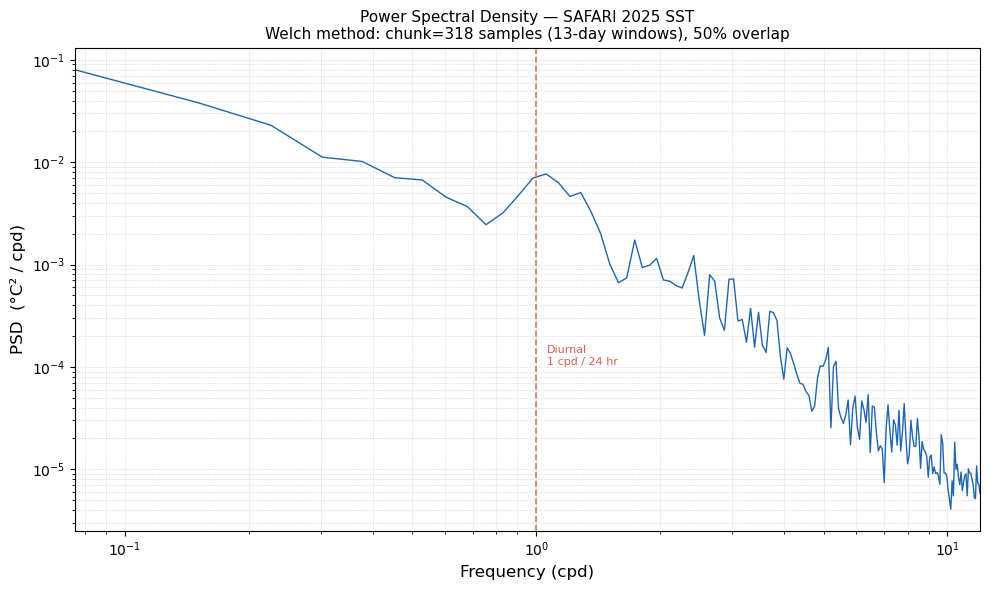

In [10]:
# YOUR CODE HERE — plot the SST PSD on a log-log scale
# Include: axis labels, title, grid, at least one reference line
%matplotlib inline

import matplotlib.pyplot as plt

# ── Plot PSD on log-log scale ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.loglog(f_sst[1:], psd_sst[1:], color='#2166ac', linewidth=1.0)

# Reference line: diurnal frequency
ax.axvline(1.0, color='#d6604d', linewidth=1.2, linestyle='--', alpha=0.85)
ax.text(1.0 * 1.06, 1e-4, 'Diurnal\n1 cpd / 24 hr', color='#d6604d', fontsize=8, va='bottom')

ax.set_xlabel('Frequency (cpd)', fontsize=12)
ax.set_ylabel('PSD  (°C² / cpd)', fontsize=12)
ax.set_title(
    'Power Spectral Density — SAFARI 2025 SST\n'
    f'Welch method: chunk={chunk} samples ({T_seg:.0f}-day windows), 50% overlap',
    fontsize=11
)
ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.5)
ax.set_xlim(f_sst[1], f_sst[-1])

fig.tight_layout()
plt.show()

## Reflection

Answer the following in the cell below.

**Q1.** How many chunks did you choose and why? What frequency resolution did that give you?

**Q2.** Identify at least one spectral peak. What is its frequency and period? What physical process do you think drives SST variability at that timescale at this location in the North Pacific?

**Q3.** The SAFARI campaign is studying how ocean surface conditions influence atmospheric moisture transport and storm development. Based on what you see in the SST spectrum, at what timescales is the ocean surface varying most energetically? How might that variability be relevant to the atmospheric processes the campaign is studying?

Q1: I chose 10 chunks, which gave a chunk size of 318 samples. Using the Welch's method (with 50% overlap), this provides us with 19 segments to average together. The frequency resolution is ~0.075 cpd, giving us a chunk size of ~13.3 days.

The slowest oscillation I can detect is one that completes a full cycle within the chunk size of ~13 days. This means the diurnal cycle (which is once a day) shows up clearly, as it is less than the chunk size.

If I had used a fewer amount of chunks, I would have gotten larger chunk sizes and been able to detect longer cycles. However, less chunks means fewer segments to average. This would make the spectrum generally rougher and less reliable. On the other hand, using a larger amount of chunks of lesser size would have given us a very smooth and reliable spectrum, but I would only be able to see cycles slower than a few days.

The reason why I chose 10 chunks is because it is the middle ground of the two. 19 segments gives us a relatively smooth and reliable spectrum, while also allowing us to capture cycles that are important, like the diurnal peak.

Q2: The spectral peak I identified is the diurnal peak. The dominant peak is around ~1 cycle per day, meaning the SST rises and falls once every 24 hours. This relates directly to our daily heating cycle where the sun warms the ocean surface during the day and the ocean loses heat back to the atmosphere at night.

Because the buoy is in the middle of the open ocean in the North Pacific, there are few external factors to affect its readings. Closer to the coastline, things like wind and waves can cause issues. The cycle here is purely based on sunlight and heat loss as a result of the absence of the sun.

The spectrum is able to show the peak clearly in the figure, giving us a sanity check that our buoy instruments are properly picking up temperature changes.

Q3: Looking at the spectrum, the ocean temperature is changing the most in the lower frequency section. There is a particular peak seen at the diurnal cycle and the cycles that last several days to weeks. The higher PSD means that the SST is oscillating at that timescale. This just means there is a large temperature swing occurring.  

For the diurnal cycle, the daily heating and cooling affects the atmosphere above it. A warmer ocean surface during the day makes the air above it more humid and moist. At night, the surface cools and the air becomes drier. This matters particularly for SAFARI because a warmer ocean surface evaporates more water into the atmosphere, feeding moisture into storm clouds. To understand storm development, the time of day matters to fully understand the scope of moisture in the air.

For cycles that take several days to weeks, storms and weather abnormalities passing over the buoy cause big fluctuations in SST. This matters for SAFARI because these slow SST changes affect how much moisture is evaporated into the atmosphere. A storm that warms or cools the surface of the ocean for over a week has a large impact on atmospheric moisture and its effect on storm development. 
